# ML Model Training

Train XGBoost model to predict asset returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load feature data
try:
    features_df = pd.read_csv('features_data.csv', index_col=0, parse_dates=True)
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
except:
    print("Generating features...")
    returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
    features_df = returns[stocks].copy()
    for stock in stocks:
        for lag in range(1, 6):
            features_df[f'{stock}_lag{lag}'] = features_df[stock].shift(lag)
        features_df[f'{stock}_ma5'] = features_df[stock].rolling(5).mean()
        features_df[f'{stock}_ma20'] = features_df[stock].rolling(20).mean()
        features_df[f'{stock}_vol5'] = features_df[stock].rolling(5).std()
        features_df[f'{stock}_momentum'] = features_df[stock].diff()
    features_df = features_df.dropna()

In [2]:
# Prepare training data
# Create target: predict AAPL next-day return
X = features_df.iloc[:-1].values
y = features_df['AAPL'].shift(-1).iloc[:-1].values

# Remove NaN values
valid_idx = ~np.isnan(y)
X = X[valid_idx]
y = y[valid_idx]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (1238, 70)
Target shape: (1238,)


In [3]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 990 samples
Test set: 248 samples


In [4]:
# Train XGBoost model
model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training XGBoost model...")
model.fit(X_train, y_train, verbose=False)
print("✓ Model training complete")

Training XGBoost model...
✓ Model training complete


In [5]:
# Model evaluation
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"\nTrain Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.6f}")
print(f"  MAE: {train_mae:.6f}")
print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAE: {test_mae:.6f}")
print("="*50)


MODEL PERFORMANCE

Train Set:
  R² Score: 0.9127
  RMSE: 0.004474
  MAE: 0.003422

Test Set:
  R² Score: -0.1071
  RMSE: 0.012632
  MAE: 0.008773


In [6]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': features_df.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print("-"*40)
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features:
----------------------------------------
      Feature  Importance
    MSFT_ma20    0.033410
 XOM_momentum    0.024103
    MSFT_lag2    0.021520
     XOM_vol5    0.020833
NVDA_momentum    0.020582
     XOM_lag1    0.020157
AAPL_momentum    0.020120
   GOOGL_lag3    0.019727
    MSFT_vol5    0.019516
     XOM_ma20    0.018362
    GOOGL_ma5    0.017855
    AMZN_lag5    0.017569
   GOOGL_ma20    0.017409
   GOOGL_lag1    0.017101
     XOM_lag5    0.016640


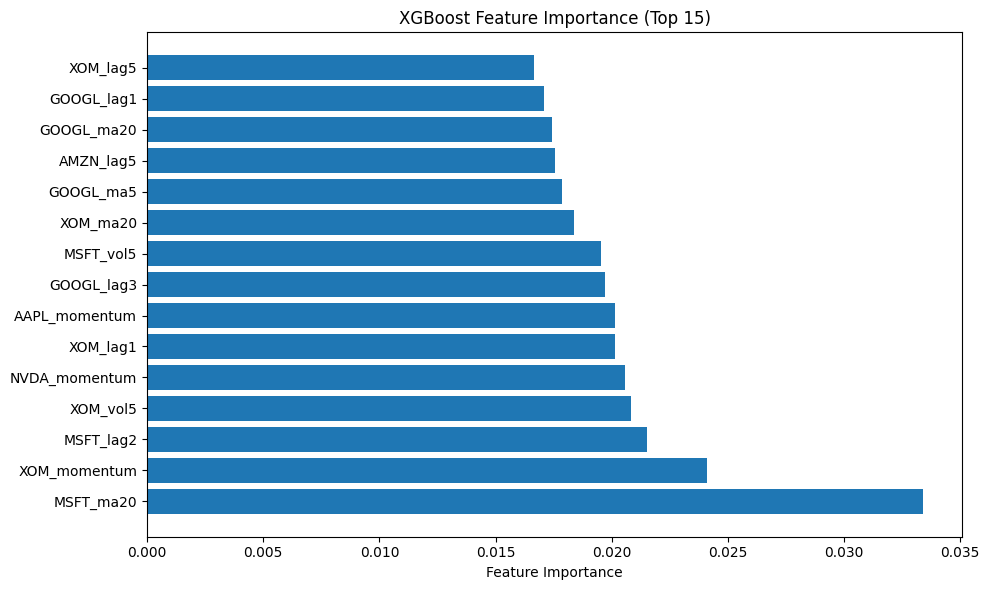

In [7]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values)
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

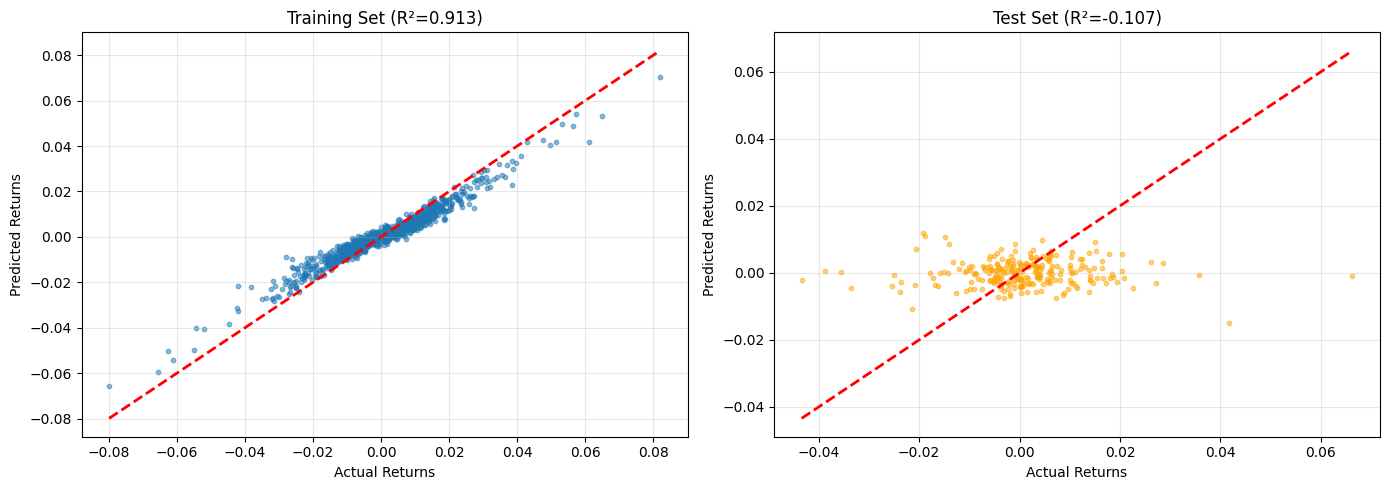

In [8]:
# Predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Returns')
axes[0].set_ylabel('Predicted Returns')
axes[0].set_title(f'Training Set (R²={train_r2:.3f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=10, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Returns')
axes[1].set_ylabel('Predicted Returns')
axes[1].set_title(f'Test Set (R²={test_r2:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

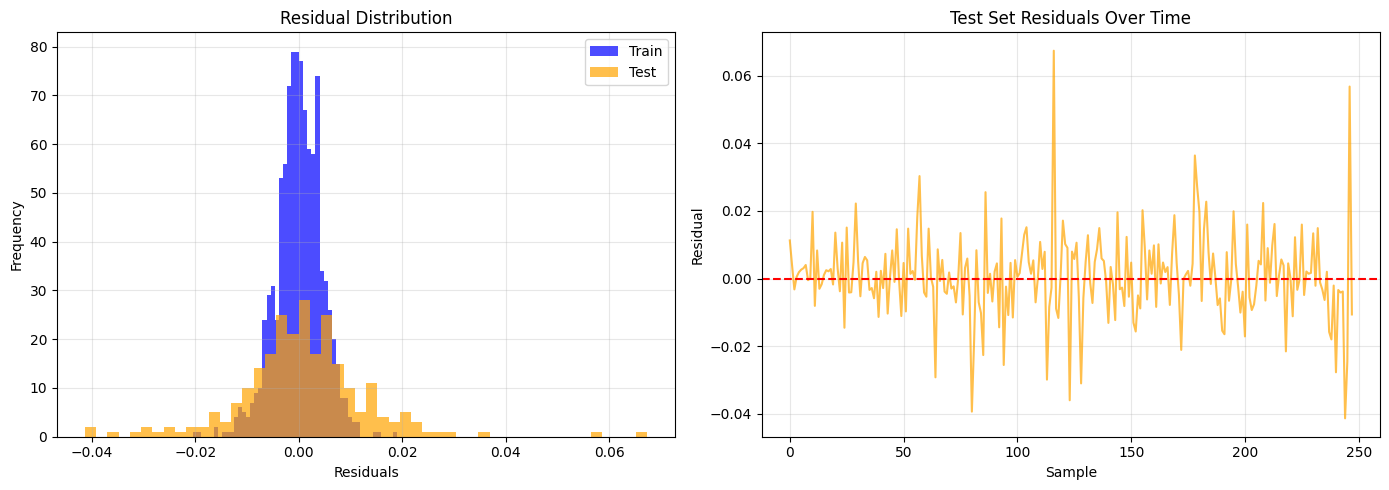

In [9]:
# Residuals analysis
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_residuals, bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(test_residuals, bins=50, alpha=0.7, label='Test', color='orange')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_residuals, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Residual')
axes[1].set_title('Test Set Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("\n✓ ML Model Training Complete")
print(f"\nModel ready for predictions:")
print(f"  • Model type: XGBoost Regressor")
print(f"  • Test R² Score: {test_r2:.4f}")
print(f"  • Top predictor: {feature_importance.iloc[0]['Feature']}")


✓ ML Model Training Complete

Model ready for predictions:
  • Model type: XGBoost Regressor
  • Test R² Score: -0.1071
  • Top predictor: MSFT_ma20


In [11]:
# Save model for backtesting
model.save_model('xgboost_model.json')
feature_importance.to_csv('feature_importance.csv', index=False)
print("✓ Model and feature importance saved")

✓ Model and feature importance saved
